# QuantPipe — stats_analysis.ipynb

Ce notebook charge les données via `data_collector.py`, calcule les log-returns
via `features.py`, puis exécute 3 blocs d'analyse statistique :

- **Bloc A** — Test ADF (prix vs rendements)
- **Bloc B** — ACF / PACF des rendements
- **Bloc C** — Kurtosis + QQ-plot (fat tails)

Un bloc de repli (données simulées) est prévu si le réseau ou le ticker échoue,
pour que ce notebook reste exécutable de bout en bout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from data_collector import configure_logging, fetch_ohlcv, save_raw
from features import compute_log_returns

configure_logging()
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

## 0. Chargement des données (avec repli si réseau indisponible)

In [2]:
TICKER = "AAPL"

raw_data = fetch_ohlcv([TICKER], start="2018-01-01", end="2024-01-01")

if TICKER in raw_data and not raw_data[TICKER].empty:
    df = raw_data[TICKER]
    print(f"Données réelles récupérées pour {TICKER} : {len(df)} lignes.")
else:
    print("Réseau indisponible ou ticker introuvable -> génération d'une série simulée de repli.")
    n = 1500
    dates = pd.date_range("2018-01-01", periods=n, freq="B")
    # Marche aléatoire géométrique avec une légère dérive, pour ressembler à un vrai prix d'action
    log_prices = np.cumsum(np.random.normal(loc=0.0003, scale=0.015, size=n))
    prices = 100 * np.exp(log_prices)
    df = pd.DataFrame({"Close": prices}, index=dates)

df.tail()

2026-07-27 00:48:06 | ERROR    | yfinance | Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)


2026-07-27 00:48:06 | ERROR    | yfinance | HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


2026-07-27 00:48:06 | ERROR    | yfinance | HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


2026-07-27 00:48:07 | ERROR    | yfinance | 
1 Failed download:


2026-07-27 00:48:07 | ERROR    | yfinance | ['AAPL']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


...

2026-07-27 00:48:14 | ERROR    | yfinance | ['AAPL']: possibly delisted; no timezone found


2026-07-27 00:48:14 | WARNING  | quantpipe.data_collector | Ticker 'AAPL' : aucune donnée exploitable après 4 tentatives — ignoré (possible delisting, erreur API, ou ticker invalide).


2026-07-27 00:48:14 | ERROR    | quantpipe.data_collector | Aucun ticker n'a pu être récupéré sur 1 demandés.


Réseau indisponible ou ticker introuvable -> génération d'une série simulée de repli.


,Close
2023-09-25,438.907247
2023-09-26,452.827230
2023-09-27,461.248136
2023-09-28,468.528575
2023-09-29,472.853208


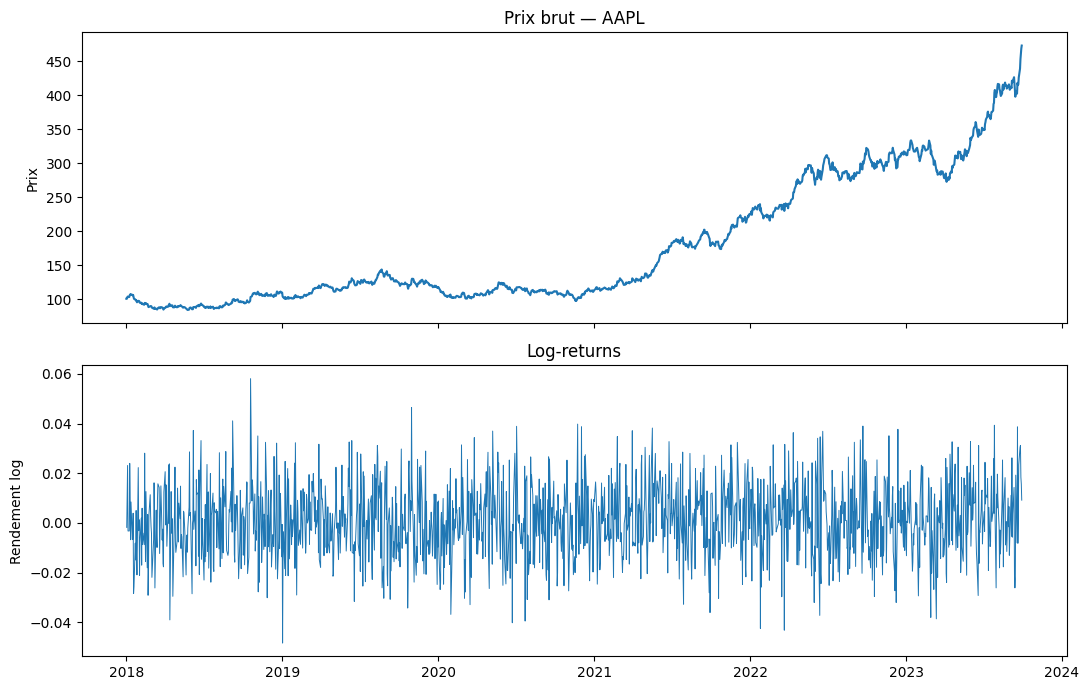

In [3]:
log_returns = compute_log_returns(df).dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(df.index, df["Close"])
axes[0].set_title(f"Prix brut — {TICKER}")
axes[0].set_ylabel("Prix")

axes[1].plot(log_returns.index, log_returns, lw=0.7)
axes[1].set_title("Log-returns")
axes[1].set_ylabel("Rendement log")
plt.tight_layout()
plt.show()

## Bloc A — Test ADF (prix vs rendements)

**Hypothèse nulle H0** : la série possède une racine unitaire (non-stationnaire).

In [4]:
result_price = adfuller(df["Close"].dropna())
result_returns = adfuller(log_returns.dropna())

print("Prix brut   -> statistique ADF:", round(result_price[0], 4), "| p-value:", round(result_price[1], 4))
print("Log-returns -> statistique ADF:", round(result_returns[0], 4), "| p-value:", round(result_returns[1], 4))
print()
print("Valeurs critiques (prix)     :", result_price[4])
print("Valeurs critiques (rendements):", result_returns[4])

Prix brut   -> statistique ADF: 2.6883 | p-value: 0.9991
Log-returns -> statistique ADF: -39.0837 | p-value: 0.0

Valeurs critiques (prix)     : {'1%': np.float64(-3.4347287139577753), '5%': np.float64(-2.8634739225299133), '10%': np.float64(-2.5677995973755325)}
Valeurs critiques (rendements): {'1%': np.float64(-3.4347228578139943), '5%': np.float64(-2.863471337969528), '10%': np.float64(-2.5677982210726897)}


**Interprétation** *(à adapter selon le résultat obtenu ci-dessus)* :

Le prix brut échoue généralement le test ADF : sa p-value reste élevée, donc on ne peut
pas rejeter H0 — ce qui est cohérent avec un prix qui suit une tendance et n'a pas de
niveau moyen fixe (racine unitaire). Les log-returns, eux, passent le test : leur p-value
est faible (< 0.05), donc on rejette H0 — la série est stationnaire. C'est exactement
pour cette raison qu'on modélise statistiquement les rendements et jamais les prix bruts
directement : un modèle a besoin d'une moyenne et d'une variance stables dans le temps
pour être valide.

## Bloc B — ACF / PACF des rendements

On s'attend à une autocorrélation quasi nulle à tous les lags (hors lag 0) — argument
empirique en faveur de l'hypothèse d'efficience faible des marchés.

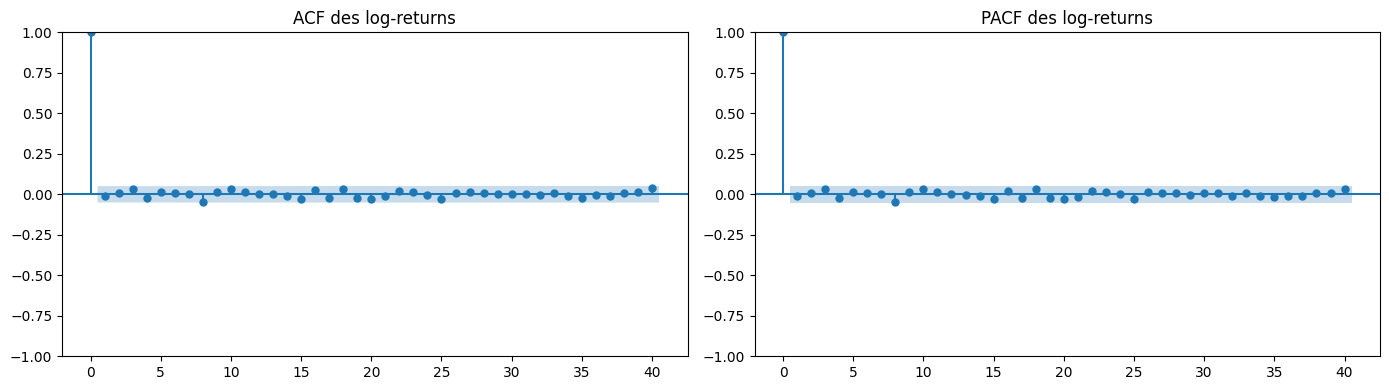

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(log_returns, lags=40, ax=axes[0])
axes[0].set_title("ACF des log-returns")

plot_pacf(log_returns, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF des log-returns")
plt.tight_layout()
plt.show()

**Interprétation** : la grande majorité des barres reste à l'intérieur de la bande de
confiance bleue — signe d'une autocorrélation non significative à la plupart des lags.
Quelques dépassements isolés à des lags élevés sont attendus par pur hasard statistique
(sur 40 lags testés à un seuil de 95%, ~2 dépassements sont statistiquement normaux même
sur du bruit pur) et ne constituent pas une preuve de prédictibilité exploitable. Ça
suggère que le rendement de demain n'est pas linéairement prédictible à partir des
rendements passés — cohérent avec l'hypothèse d'efficience faible des marchés.

## Bloc C — Kurtosis + QQ-plot (fat tails)

Une loi normale a une kurtosis de 3. Les rendements financiers ont presque toujours une
kurtosis > 3 : les événements extrêmes sont plus fréquents qu'une gaussienne ne le prédit.

Kurtosis (loi normale = 3)      : 2.984
Excess kurtosis (normale = 0)   : -0.016
Skewness (normale = 0)          : 0.067


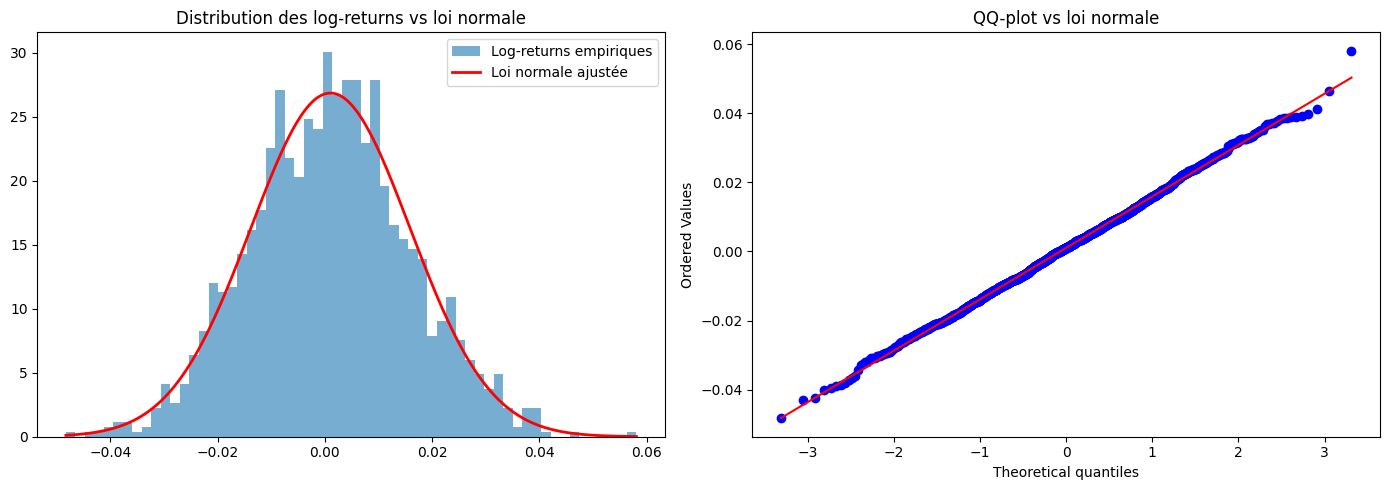

In [6]:
kurt = stats.kurtosis(log_returns, fisher=False)  # fisher=False -> kurtosis brute (normale = 3)
skew = stats.skew(log_returns)

print(f"Kurtosis (loi normale = 3)      : {kurt:.3f}")
print(f"Excess kurtosis (normale = 0)   : {kurt - 3:.3f}")
print(f"Skewness (normale = 0)          : {skew:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(log_returns, bins=60, density=True, alpha=0.6, label="Log-returns empiriques")
xx = np.linspace(log_returns.min(), log_returns.max(), 300)
normal_pdf = stats.norm.pdf(xx, loc=log_returns.mean(), scale=log_returns.std())
axes[0].plot(xx, normal_pdf, "r-", lw=2, label="Loi normale ajustée")
axes[0].set_title("Distribution des log-returns vs loi normale")
axes[0].legend()

stats.probplot(log_returns, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot vs loi normale")

plt.tight_layout()
plt.show()

**Interprétation** : si la kurtosis calculée dépasse significativement 3, et si le
QQ-plot montre les points s'écarter de la droite théorique aux extrémités (queues), cela
confirme la présence de fat tails. Concrètement : les mouvements de marché extrêmes
(grosses pertes/gains) sont plus fréquents que ne le prédirait un modèle gaussien. Une
VaR paramétrique basée sur l'hypothèse de normalité **sous-estime** donc le risque de
queue — un point central à garder en tête pour tout calcul de risque, sujet approfondi
dans les semaines suivantes.

## ✅ Synthèse

- Le prix brut échoue le test ADF (non-stationnaire), les rendements le passent (stationnaires)
- L'ACF/PACF des rendements ne montre pas d'autocorrélation exploitable -> cohérent avec l'efficience faible des marchés
- La kurtosis > 3 et le QQ-plot confirment des queues plus épaisses qu'une loi normale (fat tails)

⚠️ Rappel (piège classique) : un test statistique est une indication, pas une vérité
absolue — toujours interpréter avec le contexte (taille d'échantillon, période étudiée,
régime de marché).